Project title:
“What AI skills are most valuable in the job market?”
-Which AI skills are associated with higher salaries
-Which countries pay more for specific AI roles
-Whether the most discussed skills online are also the best paid
-Which skills seem undervalued or overhyped.

In [1]:
 import pandas as pd
df = pd.read_csv("ai_job_dataset.csv")
display(df)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [3]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

In [4]:
df = df.drop(columns=[
    'job_id',
    'job_description_length',
    'company_name',
    'application_deadline',
    'posting_date'
])

In [5]:
df['salary_currency'].unique()

array(['USD', 'EUR', 'GBP'], dtype=object)

In [6]:
df["salary_currency"].value_counts()

salary_currency
USD    11957
EUR     2314
GBP      729
Name: count, dtype: int64

In [12]:
currency_to_usd = {
    "USD": 1.0,
    "EUR": 1.1793,
    "GBP": 1.3569
}
df["salary_converted_usd"] = (
    pd.to_numeric(df["salary_usd"], errors="coerce")
    * df["salary_currency"].map(currency_to_usd)
).round(2)
df

Overall mean salary in dataset: $115,190.32
Overall median salary in dataset: $99,530.00

Top AI-specific skills by median salary:
             skill  job_count  mean_salary_converted_usd  \
3              nlp       2145              116217.931469   
2            mlops       2164              115008.062384   
1    deep learning       2189              117242.074920   
4          pytorch       2777              115527.204537   
0  computer vision       2284              115897.875219   
5       tensorflow       3022              115143.438120   

   median_salary_converted_usd  
3                     101915.0  
2                     100992.5  
1                     100603.0  
4                     100002.0  
0                      99563.5  
5                      98893.5  

Top supporting skills by median salary:
                 skill  job_count  mean_salary_converted_usd  \
11                 git       2631              116659.985177   
9               docker       1862              1

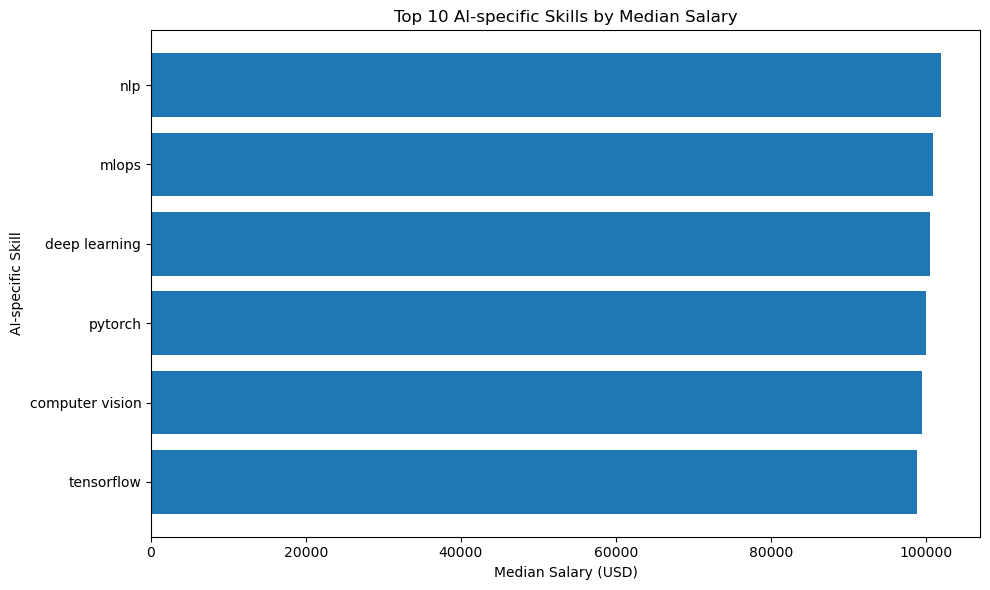

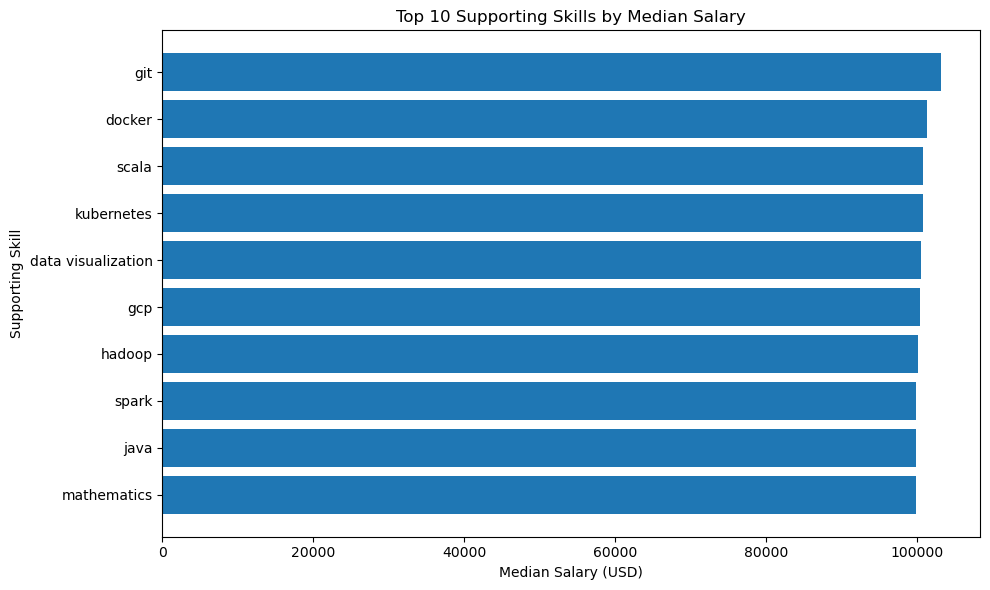

In [13]:
# Which AI skills are associated with higher salaries?

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ai_job_dataset.csv")

# 2. Basic cleaning

df["salary_converted_usd"] = pd.to_numeric(df["salary_usd"], errors="coerce")

# 3. Define AI-specific skills 

AI_SKILLS = {
    "nlp", "deep learning", "mlops",
    "computer vision", "pytorch", "tensorflow"
}

# 4. Split and explode skills

df["skill_list"] = (
    df["required_skills"]
    .astype(str)
    .str.split(",")
    .apply(lambda skills: [s.strip().lower() for s in skills if s.strip()])
)

skills_df = df.explode("skill_list").rename(columns={"skill_list": "skill"})

# 5. Classify each skill

skills_df["skill_group"] = skills_df["skill"].apply(
    lambda x: "AI-specific" if x in AI_SKILLS else "Supporting"
)
# 6. Overall salary baseline

overall_mean_salary = skills_df["salary_converted_usd"].mean()
overall_median_salary = skills_df["salary_converted_usd"].median()

# 7. Salary stats per skill 

skill_salary_stats = (
    skills_df
    .groupby(["skill_group", "skill"])
    .agg(
        job_count=("salary_converted_usd", "count"),
        mean_salary_converted_usd=("salary_converted_usd", "mean"),
        median_salary_converted_usd=("salary_converted_usd", "median"),
        std_salary_converted_usd=("salary_converted_usd", "std")
    )
    .reset_index()
)

# 8. Filter rare skills

MIN_JOB_COUNT = 30
skill_salary_filtered = skill_salary_stats[
    skill_salary_stats["job_count"] >= MIN_JOB_COUNT
].copy()

# 9. Separate outputs

ai_skill_results = (
    skill_salary_filtered[skill_salary_filtered["skill_group"] == "AI-specific"]
    .sort_values(by="median_salary_converted_usd", ascending=False)
)

supporting_skill_results = (
    skill_salary_filtered[skill_salary_filtered["skill_group"] == "Supporting"]
    .sort_values(by="median_salary_converted_usd", ascending=False)
)

# 10. Print results

print("Overall mean salary in dataset: ${:,.2f}".format(overall_mean_salary))
print("Overall median salary in dataset: ${:,.2f}".format(overall_median_salary))

print("\nTop AI-specific skills by median salary:")
print(
    ai_skill_results[
        ["skill", "job_count", "mean_salary_converted_usd", "median_salary_converted_usd"]
    ].head(15)
)

print("\nTop supporting skills by median salary:")
print(
    supporting_skill_results[
        ["skill", "job_count", "mean_salary_converted_usd", "median_salary_converted_usd"]
    ].head(15)
)

# 11. Save results

ai_skill_results.to_csv("q1_ai_specific_skill_salary.csv", index=False)
supporting_skill_results.to_csv("q1_supporting_skill_salary.csv", index=False)
skill_salary_filtered.to_csv("q1_all_skill_salary_split.csv", index=False)



In [ ]:
# 12. Plot AI-specific skills

top_ai = ai_skill_results.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_ai["skill"], top_ai["median_salary_converted_usd"])
plt.xlabel("Median Salary (USD)")
plt.ylabel("AI-specific Skill")
plt.title("Top 10 AI-specific Skills by Median Salary")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 13. Plot supporting skills

top_supporting = supporting_skill_results.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_supporting["skill"], top_supporting["median_salary_converted_usd"])
plt.xlabel("Median Salary (USD)")
plt.ylabel("Supporting Skill")
plt.title("Top 10 Supporting Skills by Median Salary")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show(

The analysis shows that specialized AI skills are generally associated with higher salaries. Skills such as deep learning, NLP, MLOps, and frameworks like PyTorch and TensorFlow tend to command higher median salaries compared to more general or supporting skills.

This suggests that employers place a premium on advanced, technical expertise, particularly in areas that require deeper knowledge of machine learning systems and model deployment.


Top paying countries for each AI role:
              job_title_clean company_location  job_count  median_salary
85      ai research scientist      Switzerland         41       173970.0
65      ai research scientist           Norway         37       149940.0
20      ai research scientist          Denmark         57       141983.0
90      ai research scientist   United Kingdom         26       127976.5
95      ai research scientist    United States         40       121822.0
86             data scientist      Switzerland         44       153577.5
66             data scientist           Norway         30       142563.5
1              data scientist        Australia         30       124762.0
81             data scientist           Sweden         39       123682.0
21             data scientist          Denmark         34       121106.0
22  machine learning engineer          Denmark         45       162478.0
67  machine learning engineer           Norway         42       155670.0
97  machine

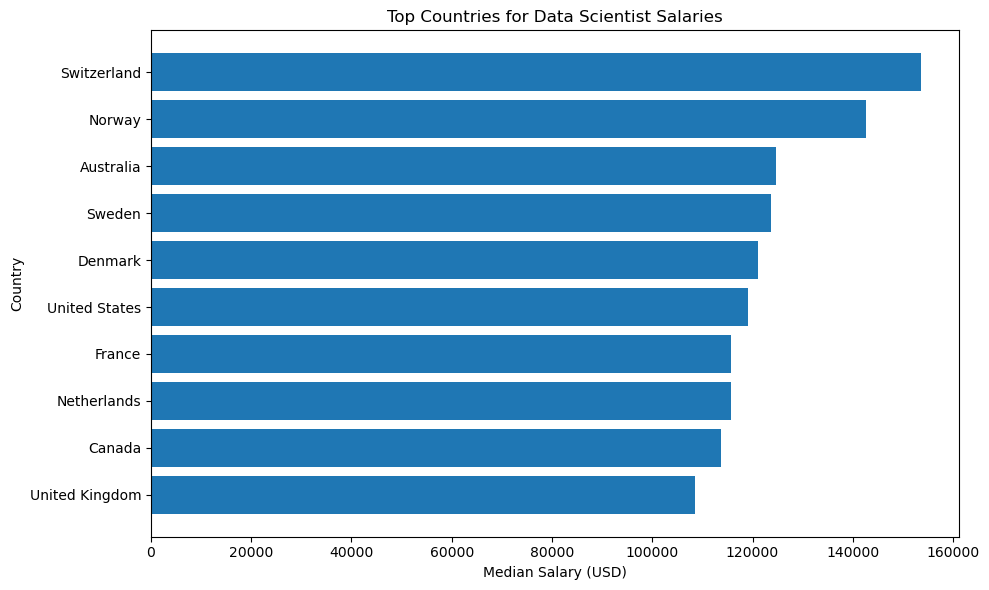

In [14]:
#which countries pay more for specefic AI roles?
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("ai_job_dataset.csv")

# Clean salary column (use correct column name from your dataset)
df["salary_converted_usd"] = pd.to_numeric(df["salary_usd"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["salary_converted_usd", "company_location", "job_title"])

# Normalize job titles
df["job_title_clean"] = df["job_title"].str.lower()

# Define AI roles
AI_ROLES = [
    "data scientist",
    "machine learning engineer",
    "ml engineer",
    "ai engineer",
    "research scientist"
]

# Filter AI roles
ai_df = df[
    df["job_title_clean"].apply(
        lambda x: any(role in x for role in AI_ROLES)
    )
]

# Group by country and role
country_role_salary = (
    ai_df
    .groupby(["company_location", "job_title_clean"])
    .agg(
        job_count=("salary_converted_usd", "count"),
        mean_salary=("salary_converted_usd", "mean"),
        median_salary=("salary_converted_usd", "median")
    )
    .reset_index()
)

# Filter low sample sizes
MIN_JOB_COUNT = 20
filtered = country_role_salary[
    country_role_salary["job_count"] >= MIN_JOB_COUNT
]

# Get top paying countries per role
top_paying = (
    filtered
    .sort_values(["job_title_clean", "median_salary"], ascending=[True, False])
    .groupby("job_title_clean")
    .head(5)
)

# Print results
print("\nTop paying countries for each AI role:")
print(top_paying[[
    "job_title_clean",
    "company_location",
    "job_count",
    "median_salary"
]])

# Save results
top_paying.to_csv("q2_top_paying_countries_by_role.csv", index=False)

# Plot example: Data Scientist salaries by country
role = "data scientist"

role_data = (
    filtered[filtered["job_title_clean"] == role]
    .sort_values("median_salary", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(role_data["company_location"], role_data["median_salary"])
plt.xlabel("Median Salary (USD)")
plt.ylabel("Country")
plt.title(f"Top Countries for {role.title()} Salaries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The results indicate that European countries—especially Switzerland, Norway, and Denmark—consistently offer the highest salaries across multiple AI roles.

Switzerland leads for roles like AI Research Scientist and Data Scientist
Denmark offers top salaries for Machine Learning Engineers and senior roles
Norway also ranks highly across several roles

Interestingly, while the United States remains competitive, it does not dominate all categories, highlighting that high-paying AI opportunities are globally distributed.


Top 10 Most Frequent Skills:
         skill  job_count  median_salary_converted_usd
17      python       4450                      98320.0
21         sql       3407                      97624.0
5   tensorflow       3022                      98893.5
14  kubernetes       3009                     100812.0
19       scala       2794                     100814.0
4      pytorch       2777                     100002.0
15       linux       2705                      97627.0
11         git       2631                     103182.0
13        java       2578                      99853.5
10         gcp       2442                     100390.0

Top 10 Highest Paying Skills:
                 skill  job_count  median_salary_converted_usd
11                 git       2631                     103182.0
3                  nlp       2145                     101915.0
9               docker       1862                     101333.0
2                mlops       2164                     100992.5
19               sc

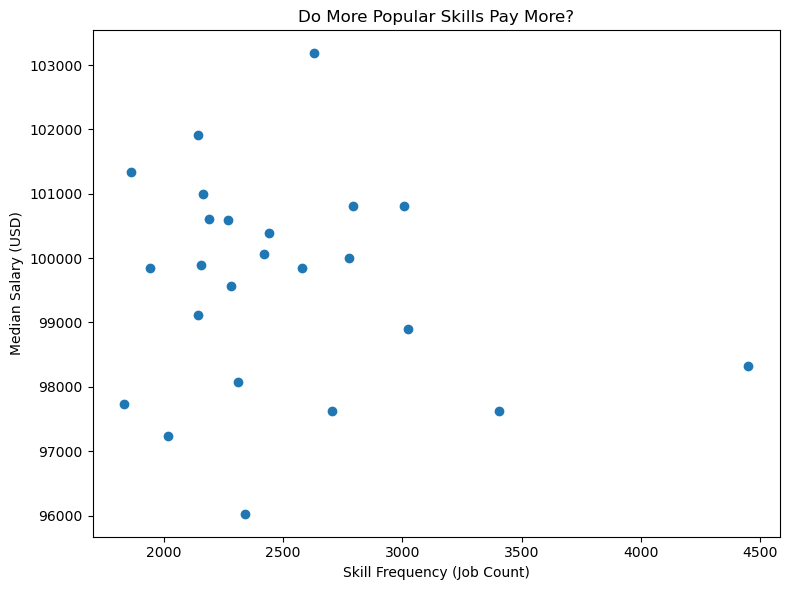

In [16]:
#Are the most discussed (most frequent) skills also the highest paid?
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("q1_all_skill_salary_split.csv")

# 1. Top most frequent skills (most discussed)
top_frequent = df.sort_values(by="job_count", ascending=False).head(10)

# 2. Top highest paying skills
top_paying = df.sort_values(by="median_salary_converted_usd", ascending=False).head(10)

# 3. Print both
print("\nTop 10 Most Frequent Skills:")
print(top_frequent[["skill", "job_count", "median_salary_converted_usd"]])

print("\nTop 10 Highest Paying Skills:")
print(top_paying[["skill", "job_count", "median_salary_converted_usd"]])

# 4. Merge to compare overlap
comparison = pd.merge(
    top_frequent[["skill"]],
    top_paying[["skill"]],
    on="skill",
    how="inner"
)

print("\nSkills that are BOTH frequent AND high-paying:")
print(comparison)

# 5. Scatter plot 
plt.figure(figsize=(8, 6))
plt.scatter(df["job_count"], df["median_salary_converted_usd"])

plt.xlabel("Skill Frequency (Job Count)")
plt.ylabel("Median Salary (USD)")
plt.title("Do More Popular Skills Pay More?")

plt.tight_layout()
plt.show()

The findings show that the most frequently mentioned (popular) skills are not necessarily the highest paying.

Although some overlap exists, many high-demand skills offer only moderate salaries. In contrast, the highest-paying skills tend to be more specialized and less commonly listed.

This indicates a weak relationship between popularity and salary, meaning that simply learning widely used skills does not guarantee higher earnings.

In [17]:
#which skills seem undervalued or overhyped
import pandas as pd

# processed data
df = pd.read_csv("q1_all_skill_salary_split.csv")

# Remove very small samples
df = df[df["job_count"] >= 30]

# Define thresholds 
high_demand = df["job_count"].quantile(0.75)
low_demand = df["job_count"].quantile(0.25)

high_salary = df["median_salary_converted_usd"].quantile(0.75)
low_salary = df["median_salary_converted_usd"].quantile(0.25)

# Overhyped: high demand, low salary
overhyped = df[
    (df["job_count"] >= high_demand) &
    (df["median_salary_converted_usd"] <= low_salary)
].sort_values(by="job_count", ascending=False)

# Undervalued: low demand, high salary
undervalued = df[
    (df["job_count"] <= low_demand) &
    (df["median_salary_converted_usd"] >= high_salary)
].sort_values(by="median_salary_converted_usd", ascending=False)

# Print results
print("\nOverhyped skills (high demand, lower pay):")
print(overhyped[["skill", "job_count", "median_salary_converted_usd"]].head(10))

print("\nUndervalued skills (low demand, high pay):")
print(undervalued[["skill", "job_count", "median_salary_converted_usd"]].head(10))

# Save results
overhyped.to_csv("q3_overhyped_skills.csv", index=False)
undervalued.to_csv("q3_undervalued_skills.csv", index=False)


Overhyped skills (high demand, lower pay):
   skill  job_count  median_salary_converted_usd
21   sql       3407                      97624.0

Undervalued skills (low demand, high pay):
    skill  job_count  median_salary_converted_usd
3     nlp       2145                     101915.0
9  docker       1862                     101333.0


The analysis identifies two important patterns:

Overhyped skills: Frequently mentioned but relatively lower-paying
→ These are often common, widely taught skills with high supply
Undervalued skills: Less frequent but high-paying
→ These tend to be niche, advanced, or harder-to-master skills

This highlights that rarity and specialization are key drivers of higher salaries, rather than popularity alone.

Across all analyses, a consistent pattern emerges:
higher salaries in the AI job market are driven more by specialization, expertise, and geographic factors than by skill popularity alone.

Professionals who focus on:

advanced AI techniques
niche or less saturated skills
and high-paying geographic markets

are more likely to achieve higher compensation.